# 00 — Fairness EDA: Jigsaw Unintended Bias

Audit **dataset-level bias** across identity subgroups using three complementary, label-only methods (no model required).

| § | Method | What it answers |
|---|--------|-----------------|
| 2 | **Representation imbalance** | How often is each identity mentioned in the data? |
| 3 | **Toxic rate / Lift / DP gap** | Are some identities labelled toxic more often? |
| 4 | **Residual analysis (partial r)** | Net linear association of each identity with `target`, controlling for co-mentions. |

All subgroup vs. background comparisons in §3–§4 use the **annotated subset** (~405K rows that have identity annotations). §2 uses the full corpus.

> **Authorship note.** Claude Opus was used to help generate code and polish the writing in this notebook. The choice of methods, analysis of limitations, and interpretation of results were done by the author.

## 0. Setup

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression

from fairness_jigsaw.metrics import DEFAULT_IDENTITY_COLUMNS

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette("tab10")

SEED = 42
np.random.seed(SEED)

IDENTITY_COLS = list(DEFAULT_IDENTITY_COLUMNS)

IDENTITY_GROUPS = {
    "Gender":         ["male", "female", "transgender", "other_gender"],
    "Sexual Orient.": ["heterosexual", "homosexual_gay_or_lesbian", "bisexual", "other_sexual_orientation"],
    "Religion":       ["christian", "jewish", "muslim", "hindu", "buddhist", "atheist", "other_religion"],
    "Race/Ethnicity": ["black", "white", "asian", "latino", "other_race_or_ethnicity"],
    "Disability":     ["physical_disability", "intellectual_or_learning_disability",
                       "psychiatric_or_mental_illness", "other_disability"],
}
PALETTE = {"Gender": "#4C72B0", "Sexual Orient.": "#DD8452",
           "Religion": "#55A868", "Race/Ethnicity": "#C44E52", "Disability": "#8172B2"}

def group_colors(names):
    cols = []
    for name in names:
        for grp, members in IDENTITY_GROUPS.items():
            if name in members:
                cols.append(PALETTE[grp])
                break
        else:
            cols.append("#999999")
    return cols

TOXICITY_THRESHOLD = 0.5
ID_THRESHOLD = 0.5

## 1. Load Data

Load the full corpus, binarise each identity column (threshold ≥ 0.5), and derive a binary `toxic` label from `target`.

`df_anno` is the annotated subset — rows where at least one identity column was rated by human annotators. All subgroup-vs-background comparisons in §2–§3 run on `df_anno`, so the background consists of annotated comments that do *not* mention the identity rather than a mix of annotated and unannotated rows.

In [7]:
USE_COLS = ["id", "target"] + IDENTITY_COLS

print("Loading train.csv ...")
df = pd.read_csv("../data/train.csv", usecols=USE_COLS)

df["toxic"] = (df["target"] >= TOXICITY_THRESHOLD).astype(int)

for col in IDENTITY_COLS:
    df[f"{col}_bin"] = (df[col].fillna(0) >= ID_THRESHOLD).astype(int)
BIN_COLS = [f"{c}_bin" for c in IDENTITY_COLS]

annotated_mask = df[IDENTITY_COLS].notna().any(axis=1)
df_anno = df[annotated_mask].copy().reset_index(drop=True)

print(f"Full corpus:        {len(df):>10,} rows | toxic rate = {df['toxic'].mean():.3%}")
print(f"Annotated subset:   {len(df_anno):>10,} rows | toxic rate = {df_anno['toxic'].mean():.3%}")
print(f"Annotation coverage: {len(df_anno)/len(df):.1%} of corpus")

Loading train.csv ...
Full corpus:         1,804,874 rows | toxic rate = 7.997%
Annotated subset:      405,130 rows | toxic rate = 11.363%
Annotation coverage: 22.4% of corpus


### Observations

- The annotated subset covers only **22.4%** of the corpus (405K / 1.8M rows), yet its toxic rate (11.4%) is 3.4 pp higher than the full corpus (8.0%). The annotation process over-sampled controversial content, introducing a selection bias that should be kept in mind throughout.
- All subgroup comparisons in §2–§3 are scoped to this annotated subset to keep the background group clean.

## 2. Representation Imbalance

**Method.** For each identity, count the comments where it is flagged (binary mention ≥ 0.5) and express that as a share of the corpus:

- `n_a` = number of comments mentioning identity *a*
- `p_a` = n_a / N (mention rate)

**Purpose.** Groups with very few mentions have high statistical uncertainty in every downstream metric and are the primary candidates for reweighting or resampling at training time.

**Limitation.** Mention counts say nothing about *how* the identity is mentioned. A group discussed frequently in neutral news articles looks identical to one targeted in hate speech. Representation alone does not indicate whether the corpus is fair or harmful for that group.

Representation per identity (full corpus):
                                     n_mention   rate
female                                   53429 2.960%
male                                     44484 2.465%
christian                                40423 2.240%
white                                    25082 1.390%
muslim                                   21006 1.164%
black                                    14901 0.826%
homosexual_gay_or_lesbian                10997 0.609%
jewish                                    7651 0.424%
psychiatric_or_mental_illness             4889 0.271%
asian                                     4578 0.254%
transgender                               2499 0.138%
latino                                    2004 0.111%
atheist                                   1412 0.078%
heterosexual                              1291 0.072%
buddhist                                   588 0.033%
hindu                                      580 0.032%
other_race_or_ethnicity                

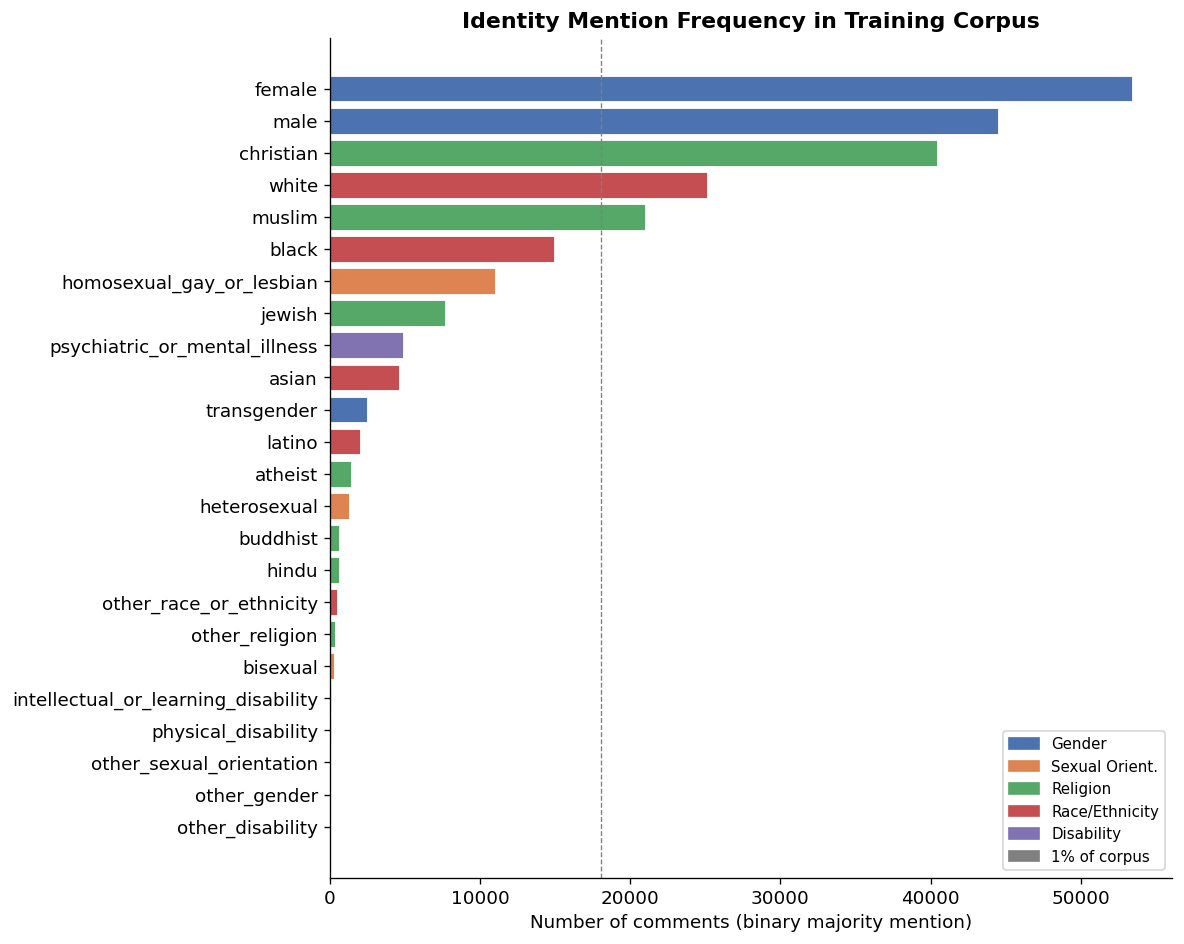

In [8]:
mention_counts = df[BIN_COLS].sum().rename(lambda x: x.replace("_bin", ""))
mention_rate = mention_counts / len(df)

rep_df = pd.DataFrame({
    "n_mention": mention_counts.astype(int),
    "rate": mention_rate,
}).sort_values("n_mention", ascending=False)

print("Representation per identity (full corpus):")
print(rep_df.to_string(formatters={"rate": "{:.3%}".format}))

fig, ax = plt.subplots(figsize=(10, 8))
sizes = mention_counts.sort_values(ascending=True)
ax.barh(sizes.index, sizes.values,
        color=group_colors(sizes.index), edgecolor="white", linewidth=0.5)
ax.axvline(len(df) * 0.01, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Number of comments (binary majority mention)")
ax.set_title("Identity Mention Frequency in Training Corpus", fontweight="bold")
patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE.items()]
ax.legend(handles=patches + [mpatches.Patch(color="gray", label="1% of corpus")],
          fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

### Observations

- **Five identities** clear the 1%-of-corpus power threshold (the dashed line, ≥ 18K mentions): `female` (2.96%), `male` (2.47%), `christian` (2.24%), `white` (1.39%), `muslim` (1.16%). Three more fall just below it but still provide moderately reliable metrics: `black` (0.83%), `homosexual_gay_or_lesbian` (0.61%), `jewish` (0.42%).
- Many categories are extremely sparse: `other_disability` has just 5 mentions, `other_gender` and `other_sexual_orientation` only 10 each — any metric for these groups carries negligible statistical weight.
- Mid-range groups (`psychiatric_or_mental_illness` 4.9K, `asian` 4.6K, `transgender` 2.5K) are usable but should be reported with appropriate uncertainty caveats.

## 3. Toxic Rate / Lift / DP Gap

**Method.** On the annotated subset, compute for each identity *a*:

- **Subgroup toxic rate** — fraction of comments mentioning *a* that are labelled toxic.
- **Baseline rate** — overall toxic rate across all annotated comments.
- **Lift** — subgroup rate ÷ baseline rate. Above 1 means the group is labelled toxic more often than the average.
- **DP gap** — subgroup rate − baseline rate (percentage points). Positive = over-labelled; negative = under-labelled.

**Purpose.** Flag identities whose toxic-label rate is inconsistent with the baseline.

**Limitation.** Lift and DP gap are confounded by co-mentions: a comment that mentions both `black` and `muslim` inflates both subgroup counts simultaneously. Disparities can therefore reflect the toxicity of *co-occurring* identities rather than the focal identity itself. §4 addresses this with partial correlation.

Annotated baseline toxic rate r0 = 11.363%

                           identity     n toxic_rate  lift   dp_gap   ci_low  ci_high
                              black 14901    31.394% 2.76x +20.031% +19.286% +20.776%
                       other_gender    10    30.000% 2.64x +18.637%  -9.766% +47.040%
           other_sexual_orientation    10    30.000% 2.64x +18.637%  -9.766% +47.040%
          homosexual_gay_or_lesbian 10997    28.380% 2.50x +17.017% +16.175% +17.860%
                              white 25082    28.060% 2.47x +16.697% +16.141% +17.253%
                       heterosexual  1291    22.773% 2.00x +11.410%  +9.122% +13.698%
                             muslim 21006    22.760% 2.00x +11.397% +10.830% +11.964%
                           bisexual   287    21.603% 1.90x +10.240%  +5.479% +15.001%
                        transgender  2499    21.289% 1.87x  +9.925%  +8.321% +11.530%
      psychiatric_or_mental_illness  4889    21.068% 1.85x  +9.705%  +8.562% +10.848%
          

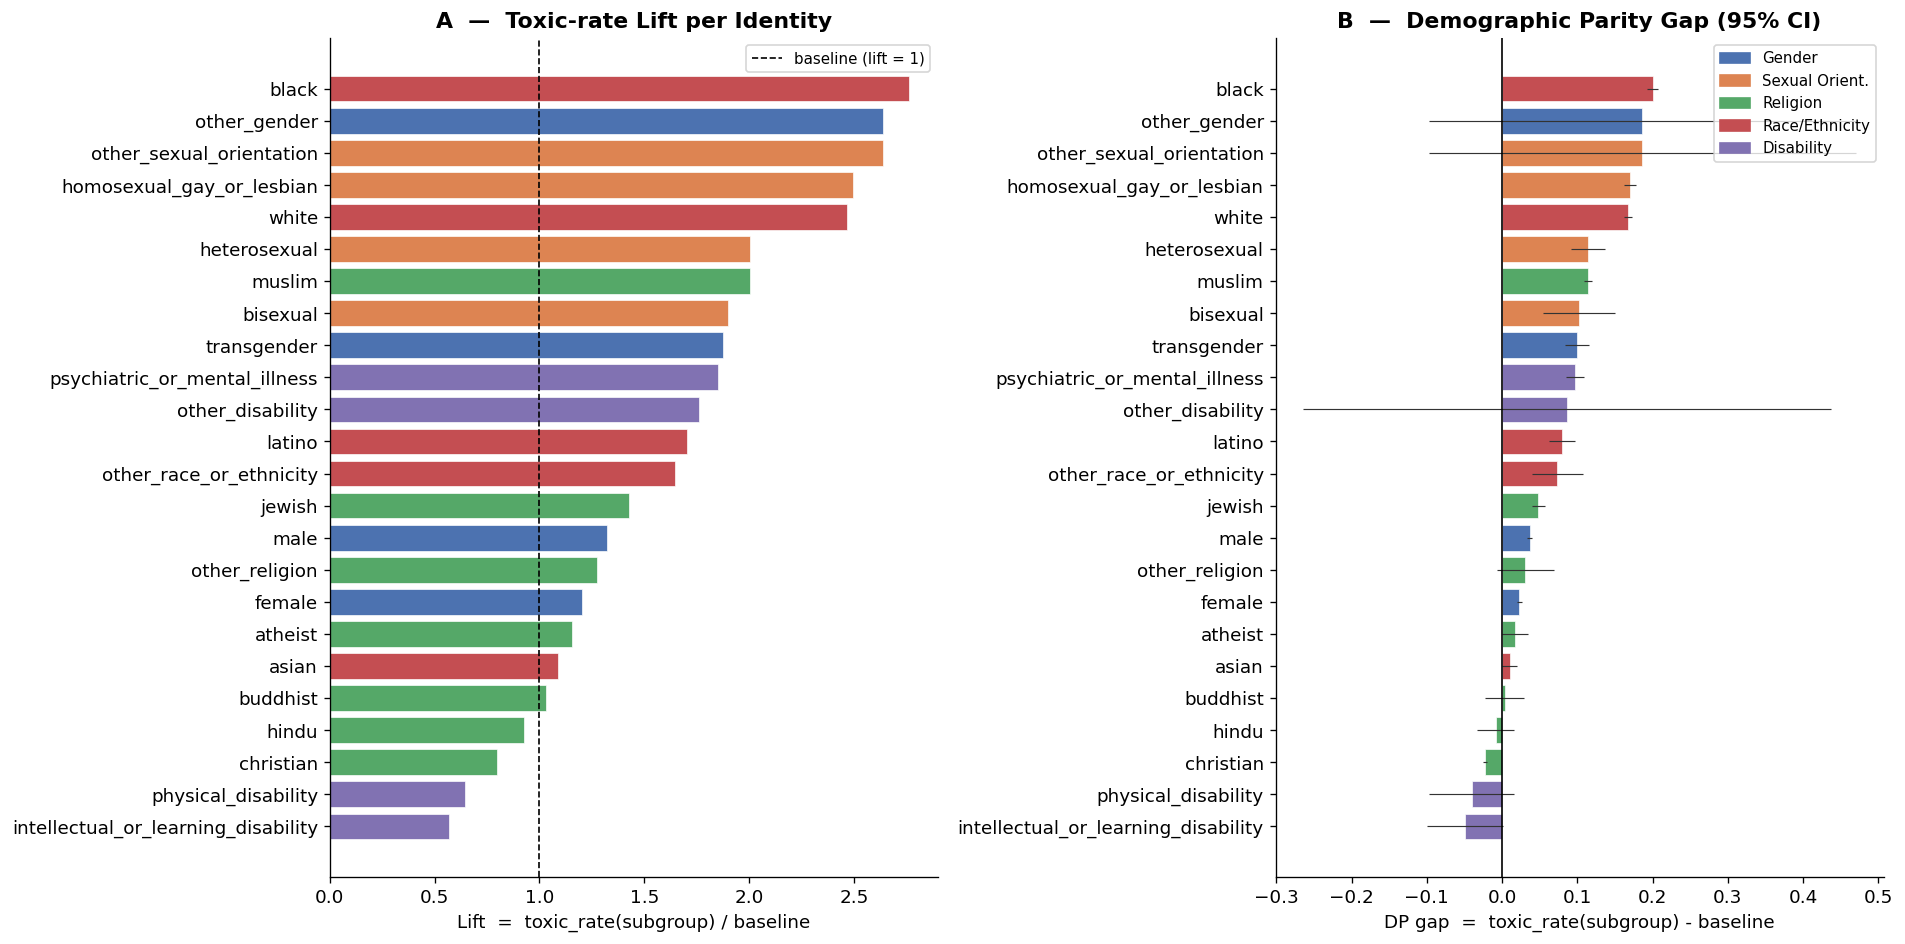

In [9]:
baseline_tox = df_anno["toxic"].mean()

dp_records = []
for col in IDENTITY_COLS:
    sub = df_anno[df_anno[f"{col}_bin"] == 1]
    if len(sub) == 0:
        continue
    rate = sub["toxic"].mean()
    se = np.sqrt(rate * (1.0 - rate) / max(len(sub), 1))
    dp_gap = rate - baseline_tox
    dp_records.append({
        "identity": col,
        "n": len(sub),
        "toxic_rate": rate,
        "lift": rate / baseline_tox if baseline_tox > 0 else np.nan,
        "dp_gap": dp_gap,
        "ci_low": dp_gap - 1.96 * se,
        "ci_high": dp_gap + 1.96 * se,
    })

dp_df = pd.DataFrame(dp_records).sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Annotated baseline toxic rate r0 = {baseline_tox:.3%}\n")
print(dp_df.to_string(index=False, formatters={
    "toxic_rate": "{:.3%}".format,
    "lift": "{:.2f}x".format,
    "dp_gap": "{:+.3%}".format,
    "ci_low": "{:+.3%}".format,
    "ci_high": "{:+.3%}".format,
}))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

dp_sorted = dp_df.sort_values("lift")
axes[0].barh(dp_sorted["identity"], dp_sorted["lift"],
             color=group_colors(dp_sorted["identity"]), edgecolor="white", linewidth=0.4)
axes[0].axvline(1.0, color="black", linestyle="--", linewidth=1, label="baseline (lift = 1)")
axes[0].set_xlabel("Lift  =  toxic_rate(subgroup) / baseline")
axes[0].set_title("A  —  Toxic-rate Lift per Identity", fontweight="bold")
axes[0].legend(fontsize=9)

dp_sorted2 = dp_df.sort_values("dp_gap")
axes[1].barh(dp_sorted2["identity"], dp_sorted2["dp_gap"],
             xerr=[dp_sorted2["dp_gap"] - dp_sorted2["ci_low"],
                   dp_sorted2["ci_high"] - dp_sorted2["dp_gap"]],
             color=group_colors(dp_sorted2["identity"]),
             edgecolor="white", linewidth=0.4, error_kw={"ecolor": "#333", "elinewidth": 0.7})
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("DP gap  =  toxic_rate(subgroup) - baseline")
axes[1].set_title("B  —  Demographic Parity Gap (95% CI)", fontweight="bold")

patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE.items()]
axes[1].legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.show()

### Observations

- Baseline toxic rate = **11.4%**. Four identities show lift > 2× with 95% CIs entirely above zero: `black` (31.4%, lift 2.76×, DP gap +20 pp), `homosexual_gay_or_lesbian` (28.4%, +17 pp), `white` (28.1%, +17 pp), `muslim` (22.8%, +11 pp).
- `other_gender` and `other_sexual_orientation` appear to have lift > 2.6×, but n = 10 each means CIs span ±30 pp — these figures are not meaningful.
- `christian` is the only major identity significantly *below* baseline (9.1%, DP gap −2.3 pp).
- These are raw, uncontrolled disparities; co-mention effects have not been removed yet — see §4.

## 4. Residual Analysis — Partial Correlation

§3 measures uncontrolled label disparity. A comment mentioning *muslim* + *black* + *female* contributes to all three subgroup rates, so §3 mixes each identity's own effect with those of every identity it co-occurs with. Partial correlation removes this confound.

**Method.** For each identity *a*:

1. **Residualise the identity flag** — regress the identity indicator on all other identity flags and keep the residual (the part of "identity *a* mentioned" not explained by co-mentions).
2. **Residualise the target** — repeat the same regression for the `target` score.
3. **Pearson-correlate the two residuals** — this is the partial correlation, net of all co-mention effects.

**Purpose.** Quantify the *independent* linear association between mentioning identity *a* and toxicity scores. Scale for this dataset: |r| > 0.05 is notable, |r| > 0.07 is strong.

**Limitation.** Residualisation only controls for *other identity variables* — it does not remove the influence of toxic language in the comment text itself. If comments mentioning `black` also tend to contain slurs or explicit hate speech, the partial *r* will be elevated regardless of whether the identity mention is the true cause. Separating identity-triggered bias from semantic toxicity requires text-level controls (e.g., embedding residuals), which are beyond the scope of this label-only audit.

Partial correlation r(identity_bin, target | other identities), annotated subset:
(Note: with N ~ 440K, p-values are mechanically tiny — read effect sizes.)

                           identity partial_r   p_value
                              white   +0.1577  0.00e+00
                             muslim   +0.1335  0.00e+00
          homosexual_gay_or_lesbian   +0.1196  0.00e+00
                              black   +0.1143  0.00e+00
      psychiatric_or_mental_illness   +0.0548 7.46e-267
                             female   +0.0501 3.74e-223
                               male   +0.0312  6.12e-88
                        transgender   +0.0291  1.21e-76
                             jewish   +0.0276  3.61e-69
                            atheist   +0.0094  2.15e-09
                       heterosexual   +0.0043  6.31e-03
                     other_religion   +0.0033  3.63e-02
           other_sexual_orientation   +0.0022  1.54e-01
                             latino   +0.0022  1.64e-01
  

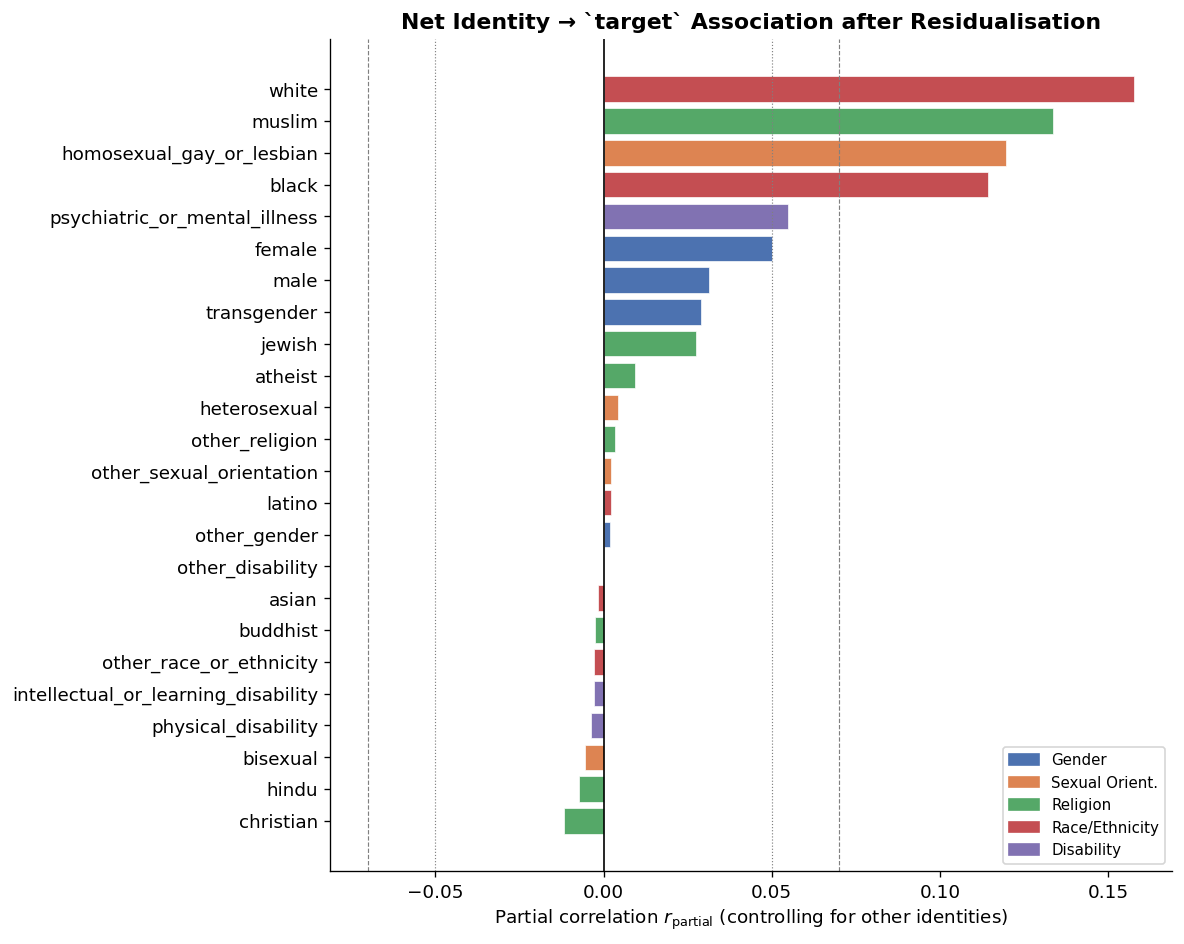

In [10]:
bin_matrix_anno = df_anno[BIN_COLS].to_numpy(dtype=float)
y_anno = df_anno["target"].to_numpy()

records = []
for i, col in enumerate(IDENTITY_COLS):
    ctrl_idx = [j for j in range(len(IDENTITY_COLS)) if j != i]
    X_ctrl  = bin_matrix_anno[:, ctrl_idx]
    x_focal = bin_matrix_anno[:, i]

    resid_y = y_anno - LinearRegression().fit(X_ctrl, y_anno).predict(X_ctrl)
    resid_x = x_focal - LinearRegression().fit(X_ctrl, x_focal).predict(X_ctrl)

    if np.std(resid_x) == 0 or np.std(resid_y) == 0:
        r, p = np.nan, np.nan
    else:
        r, p = stats.pearsonr(resid_x, resid_y)
    records.append({"identity": col, "partial_r": r, "p_value": p})

pc_df = pd.DataFrame(records).sort_values("partial_r", ascending=False).reset_index(drop=True)
print("Partial correlation r(identity_bin, target | other identities), annotated subset:")
print("(Note: with N ~ 440K, p-values are mechanically tiny — read effect sizes.)\n")
print(pc_df.to_string(index=False, formatters={"partial_r": "{:+.4f}".format, "p_value": "{:.2e}".format}))

fig, ax = plt.subplots(figsize=(10, 8))
plot_df = pc_df.sort_values("partial_r")
ax.barh(plot_df["identity"], plot_df["partial_r"],
        color=group_colors(plot_df["identity"]), edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", linewidth=1)
for thr, ls in [(0.05, ":"), (0.07, "--")]:
    ax.axvline(thr,  color="gray", linestyle=ls, linewidth=0.7)
    ax.axvline(-thr, color="gray", linestyle=ls, linewidth=0.7)
ax.set_xlabel("Partial correlation $r_{\\mathrm{partial}}$ (controlling for other identities)")
ax.set_title("Net Identity → `target` Association after Residualisation", fontweight="bold")
patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE.items()]
ax.legend(handles=patches, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

### Observations

- After controlling for co-mentions, four identities retain the strongest net positive association: `white` (+0.158), `muslim` (+0.134), `homosexual_gay_or_lesbian` (+0.120), `black` (+0.114) — all clearly above the notable threshold (|r| > 0.05).
- `black` had the highest lift in §3, but its partial *r* is slightly lower than `white` and `muslim`, indicating part of its raw disparity was driven by co-mentions with other high-toxicity identities.
- `jewish` showed a moderate DP gap in §3 but its partial *r* (+0.028) drops sharply once co-mentions are removed — largely a co-mention artifact.
- `christian` flips to negative (−0.012): controlling for co-mentions, mentions of "christian" associate with *lower* toxicity scores.
- `female` (+0.050) and `psychiatric_or_mental_illness` (+0.055) show a moderate positive association worth tracking in model evaluation.
- Sparse groups (`other_*`, `asian`, `buddhist`, etc.) all have p > 0.05 — no evidence of net labelling bias.

## Conclusion

### How to read the three views together

| § | Method | What it captures |
|---|--------|-----------------|
| §2 | Representation | Which groups lack statistical power |
| §3 | Toxic rate / Lift / DP gap | Raw label disparity vs. baseline (uncontrolled) |
| §4 | Partial correlation | Net association after removing co-mention effects |

**Decision rule:** an identity flagged by both §3 and §4 shows robust evidence of label disparity; one flagged only by §3 is likely a co-mention artifact.

---

### Summary of findings

**§2 — Representation**  
Only 5 identities clearly exceed the 1%-of-corpus power threshold; 3 more are borderline. Most `other_*` and niche categories are too sparse for reliable metrics.

**§3 — Raw label disparity**  
Against the 11.4% baseline, four identities are substantially over-labelled (95% CIs entirely above zero):

| Identity | Toxic rate | Lift | DP gap |
|----------|-----------|------|--------|
| `black` | 31.4% | 2.76× | +20 pp |
| `homosexual_gay_or_lesbian` | 28.4% | 2.50× | +17 pp |
| `white` | 28.1% | 2.47× | +17 pp |
| `muslim` | 22.8% | 2.00× | +11 pp |

`christian` is the only major group below baseline (9.1%, −2.3 pp).

**§4 — Net association (co-mention controlled)**  
The same four identities retain partial correlations of 0.11–0.16, confirming the disparities are not artifacts of co-mentioning. `jewish` and `christian` largely disappear — their §3 signal was a co-mention artifact.

---

### Recommended actions

| Priority | Identities | Action |
|----------|-----------|--------|
| **High** | `black`, `homosexual_gay_or_lesbian`, `white`, `muslim` | Primary focus for fairness evaluation (Subgroup / BPSN / BNSP AUC), label reweighting, adversarial debiasing |
| **Medium** | `female`, `male`, `psychiatric_or_mental_illness`, `transgender` | Include in evaluation; disparity is real but smaller (partial r 0.03–0.06) |
| **Low** | `jewish`, `christian` | Mostly co-mention artifacts; risk of over-correction outweighs benefit |
| **Caution** | `other_*`, `bisexual`, `hindu`, `buddhist` | Too sparse for reliable metrics; pool, drop, or collect more data before acting |

**Note:** This analysis describes label distributions in the training data, not model fairness. Whether a downstream model produces unfair predictions for these groups requires model-level metrics.